# Lasso, Ridge, Elastic-net

### 예제1

#### Data: 

In [2]:
import rpy2 
%load_ext rpy2.ipython

In [2]:
%%R 
set.seed(9999)
n<-20000
toeic<-750+rnorm(n,sd=80)
toeic[toeic>990]<-990
toeic<-round(toeic)
teps<-toeic + rnorm(n,sd=0.01)
gpa<-3.5+rnorm(n,sd=0.3)
gpa[gpa>4.5]<-4.5 
gpa<-round(gpa,1)
sal<-gpa*600+toeic*5+rnorm(n,sd=300)
sal<-round(sal)

#### Analysis: 

#### [데이터정리]

In [3]:
%%R 
X<-cbind(toeic,teps,gpa)
y<-sal 

In [4]:
%%R 
head(X)

     toeic     teps gpa
[1,]   837 837.0066 3.1
[2,]   817 816.9809 3.6
[3,]   790 789.9939 3.5
[4,]   688 687.9981 3.6
[5,]   982 981.9988 2.9
[6,]   823 823.0172 3.9


In [6]:
%R -o X,y

In [8]:
X,y

(array([[837.        , 837.00659926,   3.1       ],
        [817.        , 816.98090417,   3.6       ],
        [790.        , 789.99388281,   3.5       ],
        ...,
        [828.        , 828.00137839,   3.6       ],
        [782.        , 782.00527482,   3.7       ],
        [822.        , 822.01226229,   2.7       ]]),
 array([5668., 6168., 5966., ..., 6075., 6554., 5893.]))

### [풀이1] Ridge: 해석적풀이

In [9]:
import numpy as np

In [48]:
λ=1
λI=np.diag([λ]*3)
λI

array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]])

In [49]:
bhat_ridge=np.linalg.inv(X.T@ X + λI) @ X.T @y 

In [50]:
bhat_ridge

array([-79.208969  ,  84.21375457, 600.83093632])

### [풀이2] Ridge: `sklearn`패키지 활용

In [36]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1.0) # alpha는 lambda값임 
rlst=ridge.fit(X,y)

In [39]:
rlst.coef_

array([-79.427324  ,  84.45760997, 609.14106189])

### [풀이3] Lasso: `sklearn` 패키지 활용

In [40]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=1.0) # alpha는 lambda값임 
rlst=lasso.fit(X,y)
rlst.coef_

array([5.02994425e+00, 5.06370365e-06, 5.98333362e+02])

--> ${\tt teps}$에 해당하는 계수가 0이므로 Lasso에 의해 변수선택이 잘 되었음을 알 수 있다. 

### [풀이4] Ridge: `glmnet`패키지 활용

- 변수 표준화를 해줌
- 최적의 $\lambda$값을 찾아줌

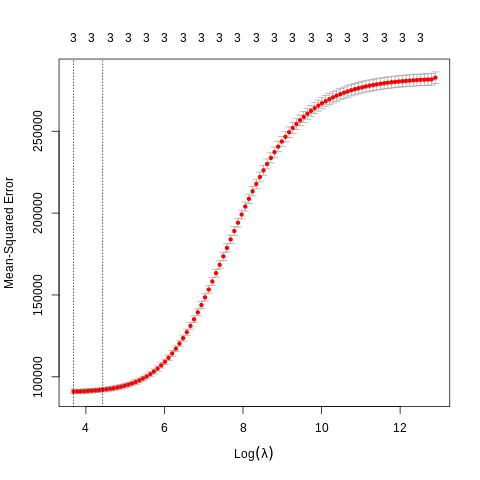

In [53]:
%%R 
library(glmnet)
cvfit_ridge<- cv.glmnet(X,y,alpha=0) ## alpha=0 : Ridge
plot(cvfit_ridge)

`cv.glmnet(X,y,alpha=0)`에서 
- `alpha=0`: Ridge
- `alpha=1`: Lasso 
- `alpha` $\in (0,1)`: Elastic-net 

왼쪽점선: 최적값 (교차검증오차의 최소값)

오른쪽점선: 최적이랑 비슷하면서 간단한 모형을 만드는 $\lambda$

In [57]:
%%R
print(log(cvfit_ridge$lambda.min))
print(log(cvfit_ridge$lambda.1se))

[1] 3.68502
[1] 4.42929


따라서 람다는 

In [59]:
%%R
print(cvfit_ridge$lambda.min)
print(cvfit_ridge$lambda.1se)

[1] 39.84592
[1] 83.87183


In [60]:
%%R 
cvfit_ridge


Call:  cv.glmnet(x = X, y = y, alpha = 0) 

Measure: Mean-Squared Error 

    Lambda Index Measure   SE Nonzero
min  39.85   100   91010 1329       3
1se  83.87    92   92113 1355       3


In [63]:
%%R 
print(coef(cvfit_ridge,s='lambda.min'))
print(coef(cvfit_ridge,s='lambda.1se'))

4 x 1 sparse Matrix of class "dgCMatrix"
                     1
(Intercept) 235.939274
toeic         2.434812
teps          2.413922
gpa         566.809663
4 x 1 sparse Matrix of class "dgCMatrix"
                     1
(Intercept) 518.590449
toeic         2.334590
teps          2.327317
gpa         526.100889


두 모형이 모두 그럴 듯 함.

(i) 토익, 텝스에 대응하는 계수합이 5이어야 하며 

(ii) 토익, 텝스의 계수값이 거의 비슷해야하는데 

이론적인 탐구내용과 일치함. 

[풀이5] Lasso: `glmnet`을 활용 

In [64]:
%%R 
library(glmnet)
cvfit_lasso<- cv.glmnet(X,y,alpha=1) 
## alpha=1 : Lasso
cvfit_lasso


Call:  cv.glmnet(x = X, y = y, alpha = 1) 

Measure: Mean-Squared Error 

    Lambda Index Measure    SE Nonzero
min  1.983    58   90644 868.0       3
1se 20.298    33   91463 859.7       3


In [65]:
%%R 
print(coef(cvfit_lasso,s='lambda.min'))
print(coef(cvfit_lasso,s='lambda.1se'))

4 x 1 sparse Matrix of class "dgCMatrix"
                        1
(Intercept) -7.508038e+00
toeic        5.004742e+00
teps         4.435535e-04
gpa          6.028313e+02
4 x 1 sparse Matrix of class "dgCMatrix"
                       1
(Intercept) 3.811478e+02
toeic       4.773224e+00
teps        2.456265e-04
gpa         5.414446e+02


### 예제 2

자료: 야구선수

In [5]:
%%R 
# install.packages("ISLR")
library(ISLR)
head(Hitters)

                  AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun
-Andy Allanson      293   66     1   30  29    14     1    293    66      1
-Alan Ashby         315   81     7   24  38    39    14   3449   835     69
-Alvin Davis        479  130    18   66  72    76     3   1624   457     63
-Andre Dawson       496  141    20   65  78    37    11   5628  1575    225
-Andres Galarraga   321   87    10   39  42    30     2    396   101     12
-Alfredo Griffin    594  169     4   74  51    35    11   4408  1133     19
                  CRuns CRBI CWalks League Division PutOuts Assists Errors
-Andy Allanson       30   29     14      A        E     446      33     20
-Alan Ashby         321  414    375      N        W     632      43     10
-Alvin Davis        224  266    263      A        W     880      82     14
-Andre Dawson       828  838    354      N        E     200      11      3
-Andres Galarraga    48   46     33      N        E     805      40      4
-Alfredo Griffin  

목표: $y$를 Salary로 설정하고 나머지를 $X$로 설정하고 회귀분석 한다. 

분석: 

단계1: missing이 보이므로 제거

In [6]:
%%R 
Hitters<-na.omit(Hitters)
head(Hitters)

                  AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun
-Alan Ashby         315   81     7   24  38    39    14   3449   835     69
-Alvin Davis        479  130    18   66  72    76     3   1624   457     63
-Andre Dawson       496  141    20   65  78    37    11   5628  1575    225
-Andres Galarraga   321   87    10   39  42    30     2    396   101     12
-Alfredo Griffin    594  169     4   74  51    35    11   4408  1133     19
-Al Newman          185   37     1   23   8    21     2    214    42      1
                  CRuns CRBI CWalks League Division PutOuts Assists Errors
-Alan Ashby         321  414    375      N        W     632      43     10
-Alvin Davis        224  266    263      A        W     880      82     14
-Andre Dawson       828  838    354      N        E     200      11      3
-Andres Galarraga    48   46     33      N        E     805      40      4
-Alfredo Griffin    501  336    194      A        W     282     421     25
-Al Newman        

단계2: $X$, $y$ 분리

In [7]:
%%R
y<- Hitters$Salary
X<- model.matrix(Salary~., Hitters)

단계3: (1) Lasso

In [11]:
%%R 
library(glmnet)
cvfit_lasso<-cv.glmnet(X,y,alpha=1)
print(coef(cvfit_lasso,s='lambda.min'))
print(coef(cvfit_lasso,s='lambda.1se'))

21 x 1 sparse Matrix of class "dgCMatrix"
                       1
(Intercept)  129.4155569
(Intercept)    .        
AtBat         -1.6130155
Hits           5.8058915
HmRun          .        
Runs           .        
RBI            .        
Walks          4.8469340
Years         -9.9724045
CAtBat         .        
CHits          .        
CHmRun         0.5374550
CRuns          0.6811938
CRBI           0.3903563
CWalks        -0.5560143
LeagueN       32.4646094
DivisionW   -119.3480842
PutOuts        0.2741895
Assists        0.1855978
Errors        -2.1650837
NewLeagueN     .        
21 x 1 sparse Matrix of class "dgCMatrix"
                      1
(Intercept) 115.3773591
(Intercept)   .        
AtBat         .        
Hits          1.4753071
HmRun         .        
Runs          .        
RBI           .        
Walks         1.6566947
Years         .        
CAtBat        .        
CHits         .        
CHmRun        .        
CRuns         0.1660465
CRBI          0.3453397
CWalks

단계3: (2) Ridge

In [12]:
%%R 
cvfit_ridge<-cv.glmnet(X,y,alpha=0)
print(coef(cvfit_ridge,s='lambda.min'))
print(coef(cvfit_ridge,s='lambda.1se'))

21 x 1 sparse Matrix of class "dgCMatrix"
                        1
(Intercept)  8.112693e+01
(Intercept)  .           
AtBat       -6.815959e-01
Hits         2.772312e+00
HmRun       -1.365680e+00
Runs         1.014826e+00
RBI          7.130225e-01
Walks        3.378558e+00
Years       -9.066800e+00
CAtBat      -1.199478e-03
CHits        1.361029e-01
CHmRun       6.979958e-01
CRuns        2.958896e-01
CRBI         2.570711e-01
CWalks      -2.789666e-01
LeagueN      5.321272e+01
DivisionW   -1.228345e+02
PutOuts      2.638876e-01
Assists      1.698796e-01
Errors      -3.685645e+00
NewLeagueN  -1.810510e+01
21 x 1 sparse Matrix of class "dgCMatrix"
                        1
(Intercept) 199.418113624
(Intercept)   .          
AtBat         0.093426871
Hits          0.389767263
HmRun         1.212875007
Runs          0.623229048
RBI           0.618547529
Walks         0.810467707
Years         2.544170910
CAtBat        0.007897059
CHits         0.030554662
CHmRun        0.226545984
CRuns 

단계3: (3) 일레스틱넷

In [15]:
%%R 
cvfit_elastic<-cv.glmnet(X,y,alpha=0.3)
print(coef(cvfit_elastic,s='lambda.min'))
print(coef(cvfit_elastic,s='lambda.1se'))

21 x 1 sparse Matrix of class "dgCMatrix"
                        1
(Intercept)  156.26926694
(Intercept)    .         
AtBat         -1.86221432
Hits           6.52255658
HmRun          1.25835153
Runs          -0.91976857
RBI            .         
Walks          5.61032321
Years         -8.13680828
CAtBat        -0.08239222
CHits          0.13867635
CHmRun         0.46738744
CRuns          0.98269057
CRBI           0.48147495
CWalks        -0.69631179
LeagueN       55.42762966
DivisionW   -118.77697469
PutOuts        0.28145542
Assists        0.30829700
Errors        -3.31699325
NewLeagueN   -20.17856311
21 x 1 sparse Matrix of class "dgCMatrix"
                        1
(Intercept) 136.364847315
(Intercept)   .          
AtBat         .          
Hits          0.877643938
HmRun         .          
Runs          0.574916107
RBI           0.550979949
Walks         1.495351453
Years         .          
CAtBat        0.003417911
CHits         0.056452154
CHmRun        0.309276663
CRuns 